In [39]:
# check the predictions and how mlflow does this
# pull these out, or generate them
# go to the scoring for defenders and work out what you can do here + what data you need
#https://www.premierleague.com/en/news/2174909/fpl-basics-scoring
# Features

Features to use:
- ~~predicted minutes~~
- ~~goal record (player or team level?)~~
- ~~assist record (player or team level?)~~
- ~~clean sheets (player + team level?)~~
- ~~defensive contributions (player + team level - also what does this mean?) [link]([company/ymiqeug7uo99i6fj8aom/asset-search-etl](https://www.premierleague.com/en/news/4361991/whats-new-in-202526-fantasy-defensive-contributions))~~
- ~~disciplinary record (player + team)~~
- ~~goals conceded (team level)~~
- ~~home vs away~~
- opposition strength

In [40]:
import duckdb
import polars as pl
from sklearn.linear_model import LinearRegression
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from fantasy_football.constants import DATA_FOLDER
from fantasy_football.storage.lookups import register_lookups
from fantasy_football.features.match_form import register_match_form
from fantasy_football.features.team_form import register_team_form

In [41]:
DATABASE_PATH = DATA_FOLDER / "fantasy_football.duckdb"
connection = duckdb.connect(DATABASE_PATH)

In [42]:
register_lookups(connection)
register_match_form(connection)
register_team_form(connection)

1 team_match rows have no kickoff_time and so no position in the rolling window; their fixture is missing from team_fixture.


In [43]:
res = connection.sql("SELECT * FROM player_week").pl()
res.head(10)

season,gw,element,name,position,team,bonus,minutes,round,total_points,value
str,i64,i64,str,str,str,i64,i64,i64,i64,i64
"""2024-25""",11,652,"""Manuel Ugarte""","""MID""","""Man Utd""",0,90,11,3,49
"""2024-25""",13,455,"""Jan Bednarek""","""DEF""","""Southampton""",0,0,13,0,40
"""2024-25""",12,76,"""Philip Billing""","""MID""","""Bournemouth""",0,0,12,0,48
"""2024-25""",26,770,"""Marshall Munetsi""","""MID""","""Wolves""",0,90,26,6,50
"""2024-25""",27,463,"""Adam Lallana""","""MID""","""Southampton""",0,0,27,0,50
"""2024-25""",3,269,"""George Edmundson""","""DEF""","""Ipswich""",0,0,3,0,40
"""2024-25""",12,145,"""Joël Veltman""","""DEF""","""Brighton""",0,90,12,2,45
"""2024-25""",21,175,"""Romelu Lukaku Bolingoli""","""FWD""","""Chelsea""",0,0,21,0,63
"""2024-25""",12,419,"""Joe White""","""MID""","""Newcastle""",0,0,12,0,45


In [44]:
match = connection.sql("SELECT * FROM player_match").pl()
match.head(10)

season,gw,element,opponent,is_home,minutes,total_points,kickoff_time
str,i64,i64,i64,bool,i64,i64,datetime[μs]
"""2024-25""",1,77,16,false,62,2,2024-08-17 14:00:00
"""2024-25""",1,427,3,true,0,0,2024-08-17 14:00:00
"""2024-25""",1,22,20,true,0,0,2024-08-17 14:00:00
"""2024-25""",1,197,4,false,0,0,2024-08-18 13:00:00
"""2024-25""",1,584,15,false,70,1,2024-08-17 14:00:00
"""2024-25""",1,52,19,false,90,2,2024-08-17 16:30:00
"""2024-25""",1,215,4,false,0,0,2024-08-18 13:00:00
"""2024-25""",1,609,11,false,0,0,2024-08-19 19:00:00
"""2024-25""",1,550,1,false,90,2,2024-08-17 14:00:00


In [45]:
minutes_prediction = connection.sql("SELECT * FROM minutes_prediction").pl()
minutes_prediction.head(10)

season,gw,element,opponent,p_zero,p_partial,p_sixty_plus,expected_minutes,model_version,prediction_kind,snapshot_captured_at
str,i64,i64,i64,f64,f64,f64,f64,str,str,datetime[μs]
"""2016-17""",1,6,9,0.180194,0.077763,0.742044,57.986142,"""7""","""backfill""",null
"""2016-17""",1,7,9,0.401603,0.077084,0.521312,41.410956,"""7""","""backfill""",null
"""2016-17""",1,11,9,0.528008,0.06779,0.404202,32.348861,"""7""","""backfill""",null
"""2016-17""",1,13,9,0.126715,0.171621,0.701664,57.773438,"""7""","""backfill""",null
"""2016-17""",1,14,9,0.044124,0.130769,0.825107,65.806122,"""7""","""backfill""",null
"""2016-17""",1,16,9,0.097705,0.16228,0.740015,60.369518,"""7""","""backfill""",null
"""2016-17""",1,17,9,0.272456,0.185248,0.542296,46.22967,"""7""","""backfill""",null
"""2016-17""",1,18,9,0.272456,0.185248,0.542296,46.22967,"""7""","""backfill""",null
"""2016-17""",1,21,9,0.272456,0.185248,0.542296,46.22967,"""7""","""backfill""",null


In [46]:
player_season = connection.sql("SELECT * FROM player_season").pl()
player_season.head(10)

season,element,player_code,web_name,first_name,second_name,position,team_code,birth_date,region,team_join_date
str,i64,i64,str,str,str,str,i64,date,i64,date
"""2016-17""",1,48844,"""Ospina""","""David""","""Ospina""","""GK""",3,null,null,null
"""2016-17""",2,11334,"""Cech""","""Petr""","""Cech""","""GK""",3,null,null,null
"""2016-17""",3,51507,"""Koscielny""","""Laurent""","""Koscielny""","""DEF""",3,null,null,null
"""2016-17""",4,17127,"""Mertesacker""","""Per""","""Mertesacker""","""DEF""",3,null,null,null
"""2016-17""",5,158074,"""Gabriel""","""Gabriel Armando""","""de Abreu""","""DEF""",3,null,null,null
"""2016-17""",6,98745,"""Bellerín""","""Héctor""","""Bellerín""","""DEF""",3,null,null,null
"""2016-17""",7,42427,"""Gibbs""","""Kieran""","""Gibbs""","""DEF""",3,null,null,null
"""2016-17""",8,27334,"""Debuchy""","""Mathieu""","""Debuchy""","""DEF""",3,null,null,null
"""2016-17""",9,80254,"""Jenkinson""","""Carl""","""Jenkinson""","""DEF""",3,null,null,null


In [47]:
base_sql = """
SELECT 
    m.season
    ,s.first_name || ' ' || s.second_name as player_name
    ,m.element
    ,m.total_points
    ,m.kickoff_time
    ,m.gw
    ,m.opponent
    ,m.minutes
    ,m.is_home
    ,mn.expected_minutes
    ,mn.p_zero
    ,mn.p_partial
    ,mn.p_sixty_plus
    ,mf.xg_per90_rolling_5
    ,mf.xa_per90_rolling_5
    ,mf.form_minutes
    ,own.xg_against_rolling_5
    ,own.goals_against_rolling_5
    ,own.clean_sheet_rolling_5
    ,opp.xg_for_rolling_5
    ,opp.goals_for_rolling_5
    ,mf.interceptions_per90_rolling_5
    ,mf.tackles_per90_rolling_5
    ,mf.clearances_per90_rolling_5
    ,mf.blocks_per90_rolling_5
    ,mf.yellow_cards_per90_rolling_5
    ,mf.red_cards_per90_rolling_5
    ,mf.yellow_cards_season_to_date
    ,mf.red_cards_season_to_date

FROM player_match m 

INNER JOIN player_season s ON m.element = s.element
    AND m.season = s.season
    AND s.position = 'DEF'
LEFT JOIN minutes_prediction mn ON m.element = mn.element
    AND m.season = mn.season
    AND m.gw = mn.gw
    AND m.element = mn.element
    AND m.opponent = mn.opponent
LEFT JOIN player_match_form mf ON m.element = mf.element
    AND m.season = mf.season
    AND m.gw = mf.gw
    AND m.opponent = mf.opponent
LEFT JOIN player_week pw ON pw.season = m.season
    AND pw.gw = m.gw
    AND pw.element = m.element
LEFT JOIN fpl_team_id opp_id ON opp_id.season = m.season
    AND opp_id.team_id = m.opponent
LEFT JOIN team_match_form own ON own.season = m.season
    AND own.gw = m.gw
    AND own.team = pw.team
    AND own.opposition = opp_id.team
LEFT JOIN team_match_form opp ON opp.season = m.season
    AND opp.gw = m.gw
    AND opp.team = opp_id.team
    AND opp.opposition = pw.team
"""

base = connection.sql(base_sql).pl()
base.head(10)


season,player_name,element,total_points,kickoff_time,gw,opponent,minutes,is_home,expected_minutes,p_zero,p_partial,p_sixty_plus,xg_per90_rolling_5,xa_per90_rolling_5,form_minutes,xg_against_rolling_5,goals_against_rolling_5,clean_sheet_rolling_5,xg_for_rolling_5,goals_for_rolling_5,interceptions_per90_rolling_5,tackles_per90_rolling_5,clearances_per90_rolling_5,blocks_per90_rolling_5,yellow_cards_per90_rolling_5,red_cards_per90_rolling_5,yellow_cards_season_to_date,red_cards_season_to_date
str,str,i64,i64,datetime[μs],i64,i64,i64,bool,f64,f64,f64,f64,f64,f64,"decimal[38,0]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]"
"""2021-22""","""Diego Llorente""",190,2,2021-08-29 13:00:00,3,5,64,false,44.527212,0.342568,0.106226,0.551206,null,null,393,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2021-22""","""Diego Llorente""",190,0,2021-09-12 15:30:00,4,11,33,true,44.467453,0.343219,0.106469,0.550312,null,null,367,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
"""2021-22""","""Diego Llorente""",190,15,2021-10-02 14:00:00,7,18,90,true,44.458286,0.343303,0.106532,0.550164,null,null,322,null,null,null,null,null,null,null,null,null,0.279503,0.0,1,0
"""2021-22""","""Diego Llorente""",190,1,2021-10-16 14:00:00,8,16,90,false,44.460904,0.343275,0.106522,0.550203,null,null,322,null,null,null,null,null,null,null,null,null,0.279503,0.0,1,0
"""2021-22""","""Diego Llorente""",190,2,2021-10-23 14:00:00,9,20,90,true,44.461778,0.343265,0.106518,0.550216,null,null,322,null,null,null,null,null,null,null,null,null,0.559006,0.0,2,0
"""2021-22""","""Diego Llorente""",190,2,2021-10-31 14:00:00,10,15,90,false,44.462654,0.343256,0.106515,0.55023,null,null,367,null,null,null,null,null,null,null,null,null,0.490463,0.0,2,0
"""2021-22""","""Diego Llorente""",190,2,2021-11-07 14:00:00,11,9,90,true,44.426799,0.343646,0.10666,0.549693,null,null,393,null,null,null,null,null,null,null,null,null,0.458015,0.0,2,0
"""2021-22""","""Diego Llorente""",190,1,2021-11-21 16:30:00,12,17,90,false,44.395132,0.343991,0.106789,0.549219,null,null,450,null,null,null,null,null,null,null,null,null,0.2,0.0,2,0
"""2021-22""","""Diego Llorente""",190,5,2021-11-27 17:30:00,13,4,90,false,44.395132,0.343991,0.106789,0.549219,null,null,450,null,null,null,null,null,null,null,null,null,0.2,0.0,2,0


In [48]:
opta_match = connection.sql("SELECT * FROM opta_match").pl()
opta_match.head(10)

season,gw,element,match_id,competition,accurate_crosses,accurate_crosses_percent,accurate_long_balls,accurate_long_balls_percent,accurate_passes,accurate_passes_percent,aerial_duels_won,aerial_duels_won_percent,assists,big_chances_missed,blocks,chances_created,clearances,corners,defensive_contributions,dispossessed,distance_covered,dribbled_past,duels_lost,duels_won,final_third_passes,finish_min,fouls_committed,gk_accurate_long_balls,gk_accurate_passes,goals,goals_conceded,goals_prevented,ground_duels_won,ground_duels_won_percent,headed_clearances,high_claim,interceptions,minutes_played,number_of_sprints,offsides,penalties_missed,penalties_scored,recoveries,running_distance,saves,saves_inside_box,shots_on_target,sprinting_distance,start_min,successful_dribbles,successful_dribbles_percent,sweeper_actions,tackles,tackles_won,tackles_won_percent,team_goals_conceded,top_speed,total_shots,touches,touches_opposition_box,walking_distance,was_fouled,xa,xg,xgot,xgot_faced,is_home,opponent
str,i64,i64,str,str,i64,f64,i64,f64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,i64,f64,i64,f64,i64,i64,i64,f64,i64,f64,f64,f64,f64,bool,i64
"""2025-26""",30,42,"""25-26-prem-manchester-united-v…","""prem""",0,0.0,0,0.0,4,100.0,0,0.0,0,0,0,0,0,null,1,1,null,0,1,1,0,96,0,0,0,0,0,0.0,1,50.0,0,0,0,4,null,0,0,0,0,null,0,0,0,null,86,0,0.0,0,1,1,100.0,0,null,0,6,0,null,0,0.005015,0.0,0.0,0.0,false,14
"""2025-26""",34,126,"""25-26-prem-manchester-united-v…","""prem""",2,22.0,5,38.0,78,85.0,0,0.0,0,0,0,1,0,null,12,1,null,0,4,2,16,96,2,0,0,1,0,0.0,2,33.0,0,0,3,90,null,0,0,0,9,null,0,0,1,null,0,1,50.0,0,0,0,0.0,2,null,2,116,0,null,1,0.396715,0.06,0.2714,0.0,false,14
"""2025-26""",26,671,"""25-26-prem-west-ham-united-vs-…","""prem""",0,0.0,0,0.0,5,100.0,1,50.0,0,0,0,0,0,null,2,1,null,0,2,1,0,96,0,0,0,0,0,0.0,0,0.0,0,0,0,21,null,0,0,0,2,null,0,0,1,null,69,0,0.0,0,0,0,0.0,1,null,2,9,1,null,0,0.009427,0.4,0.3895,0.0,true,14
"""2025-26""",16,84,"""25-26-prem-manchester-united-v…","""prem""",0,0.0,0,0.0,23,77.0,2,67.0,1,2,0,3,2,null,7,0,null,0,3,7,5,1,1,0,0,1,0,0.0,5,71.0,0,0,0,90,null,0,0,0,4,null,0,0,3,null,0,0,0.0,0,1,0,0.0,3,null,4,52,3,null,4,0.0233064,0.87,0.7064,0.0,false,14
"""2025-26""",30,50,"""25-26-prem-manchester-united-v…","""prem""",0,0.0,1,100.0,23,85.0,2,100.0,0,null,null,0,2,null,null,0,null,null,3,7,null,null,1,null,null,0,0,null,5,63.0,null,null,3,85,null,null,0,0,5,null,0,null,0,null,null,1,33.0,null,2,1,50.0,null,null,2,48,null,null,2,0.18065,0.1861,0.0,null,false,14
"""2025-26""",33,230,"""25-26-prem-chelsea-vs-manchest…","""prem""",0,0.0,2,67.0,74,95.0,3,100.0,0,0,2,0,5,null,8,0,null,0,0,3,12,81,0,0,0,0,0,0.0,0,0.0,4,0,1,80,null,0,0,0,2,null,0,0,1,null,0,0,0.0,0,0,0,0.0,1,null,2,91,3,null,0,0.009854,0.12,0.1034,0.0,true,14
"""2025-26""",13,723,"""25-26-prem-crystal-palace-vs-m…","""prem""",0,0.0,0,0.0,0,0.0,0,0.0,0,0,0,0,0,null,0,0,null,0,0,0,0,90,0,0,0,0,0,0.0,0,0.0,0,0,0,0,null,0,0,0,0,null,0,0,0,null,0,0,0.0,0,0,0,0.0,0,null,0,0,0,null,0,0.0,0.0,0.0,0.0,true,14
"""2025-26""",13,283,"""25-26-prem-crystal-palace-vs-m…","""prem""",0,0.0,0,0.0,9,64.0,3,43.0,0,1,0,0,4,null,5,0,null,1,7,6,0,90,1,0,0,1,0,0.0,3,50.0,3,0,0,90,null,0,0,1,1,null,0,0,1,null,0,1,50.0,0,0,0,0.0,2,null,4,31,5,null,2,0.005232,1.02,0.7809,0.0,true,14
"""2025-26""",18,487,"""25-26-prem-manchester-united-v…","""prem""",0,0.0,0,0.0,9,82.0,0,0.0,0,0,0,1,0,null,0,0,null,1,3,0,0,90,0,0,0,0,0,0.0,0,0.0,0,0,0,22,null,0,0,0,0,null,0,0,0,null,0,0,0.0,0,0,0,0.0,1,null,0,18,2,null,0,0.0828336,0.0,0.0,0.0,false,14


In [49]:
features = [
    "total_points",
    "is_home",
    "expected_minutes",
    "p_zero",
    "p_partial",
    "p_sixty_plus",
    "xg_per90_rolling_5",
    "xa_per90_rolling_5",
    "xg_against_rolling_5",
    "goals_against_rolling_5",
    "clean_sheet_rolling_5",
    "xg_for_rolling_5",
    "goals_for_rolling_5",
    "interceptions_per90_rolling_5",
    "tackles_per90_rolling_5",
    "clearances_per90_rolling_5",
    "blocks_per90_rolling_5",
    "yellow_cards_per90_rolling_5",
    "red_cards_per90_rolling_5",
    "yellow_cards_season_to_date",
    "red_cards_season_to_date",
]
base = base.select(features)
base.head()

total_points,is_home,expected_minutes,p_zero,p_partial,p_sixty_plus,xg_per90_rolling_5,xa_per90_rolling_5,xg_against_rolling_5,goals_against_rolling_5,clean_sheet_rolling_5,xg_for_rolling_5,goals_for_rolling_5,interceptions_per90_rolling_5,tackles_per90_rolling_5,clearances_per90_rolling_5,blocks_per90_rolling_5,yellow_cards_per90_rolling_5,red_cards_per90_rolling_5,yellow_cards_season_to_date,red_cards_season_to_date
i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]"
2,false,44.527212,0.342568,0.106226,0.551206,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
0,true,44.467453,0.343219,0.106469,0.550312,null,null,null,null,null,null,null,null,null,null,null,0.0,0.0,0,0
15,true,44.458286,0.343303,0.106532,0.550164,null,null,null,null,null,null,null,null,null,null,null,0.279503,0.0,1,0
1,false,44.460904,0.343275,0.106522,0.550203,null,null,null,null,null,null,null,null,null,null,null,0.279503,0.0,1,0
2,true,44.461778,0.343265,0.106518,0.550216,null,null,null,null,null,null,null,null,null,null,null,0.559006,0.0,2,0


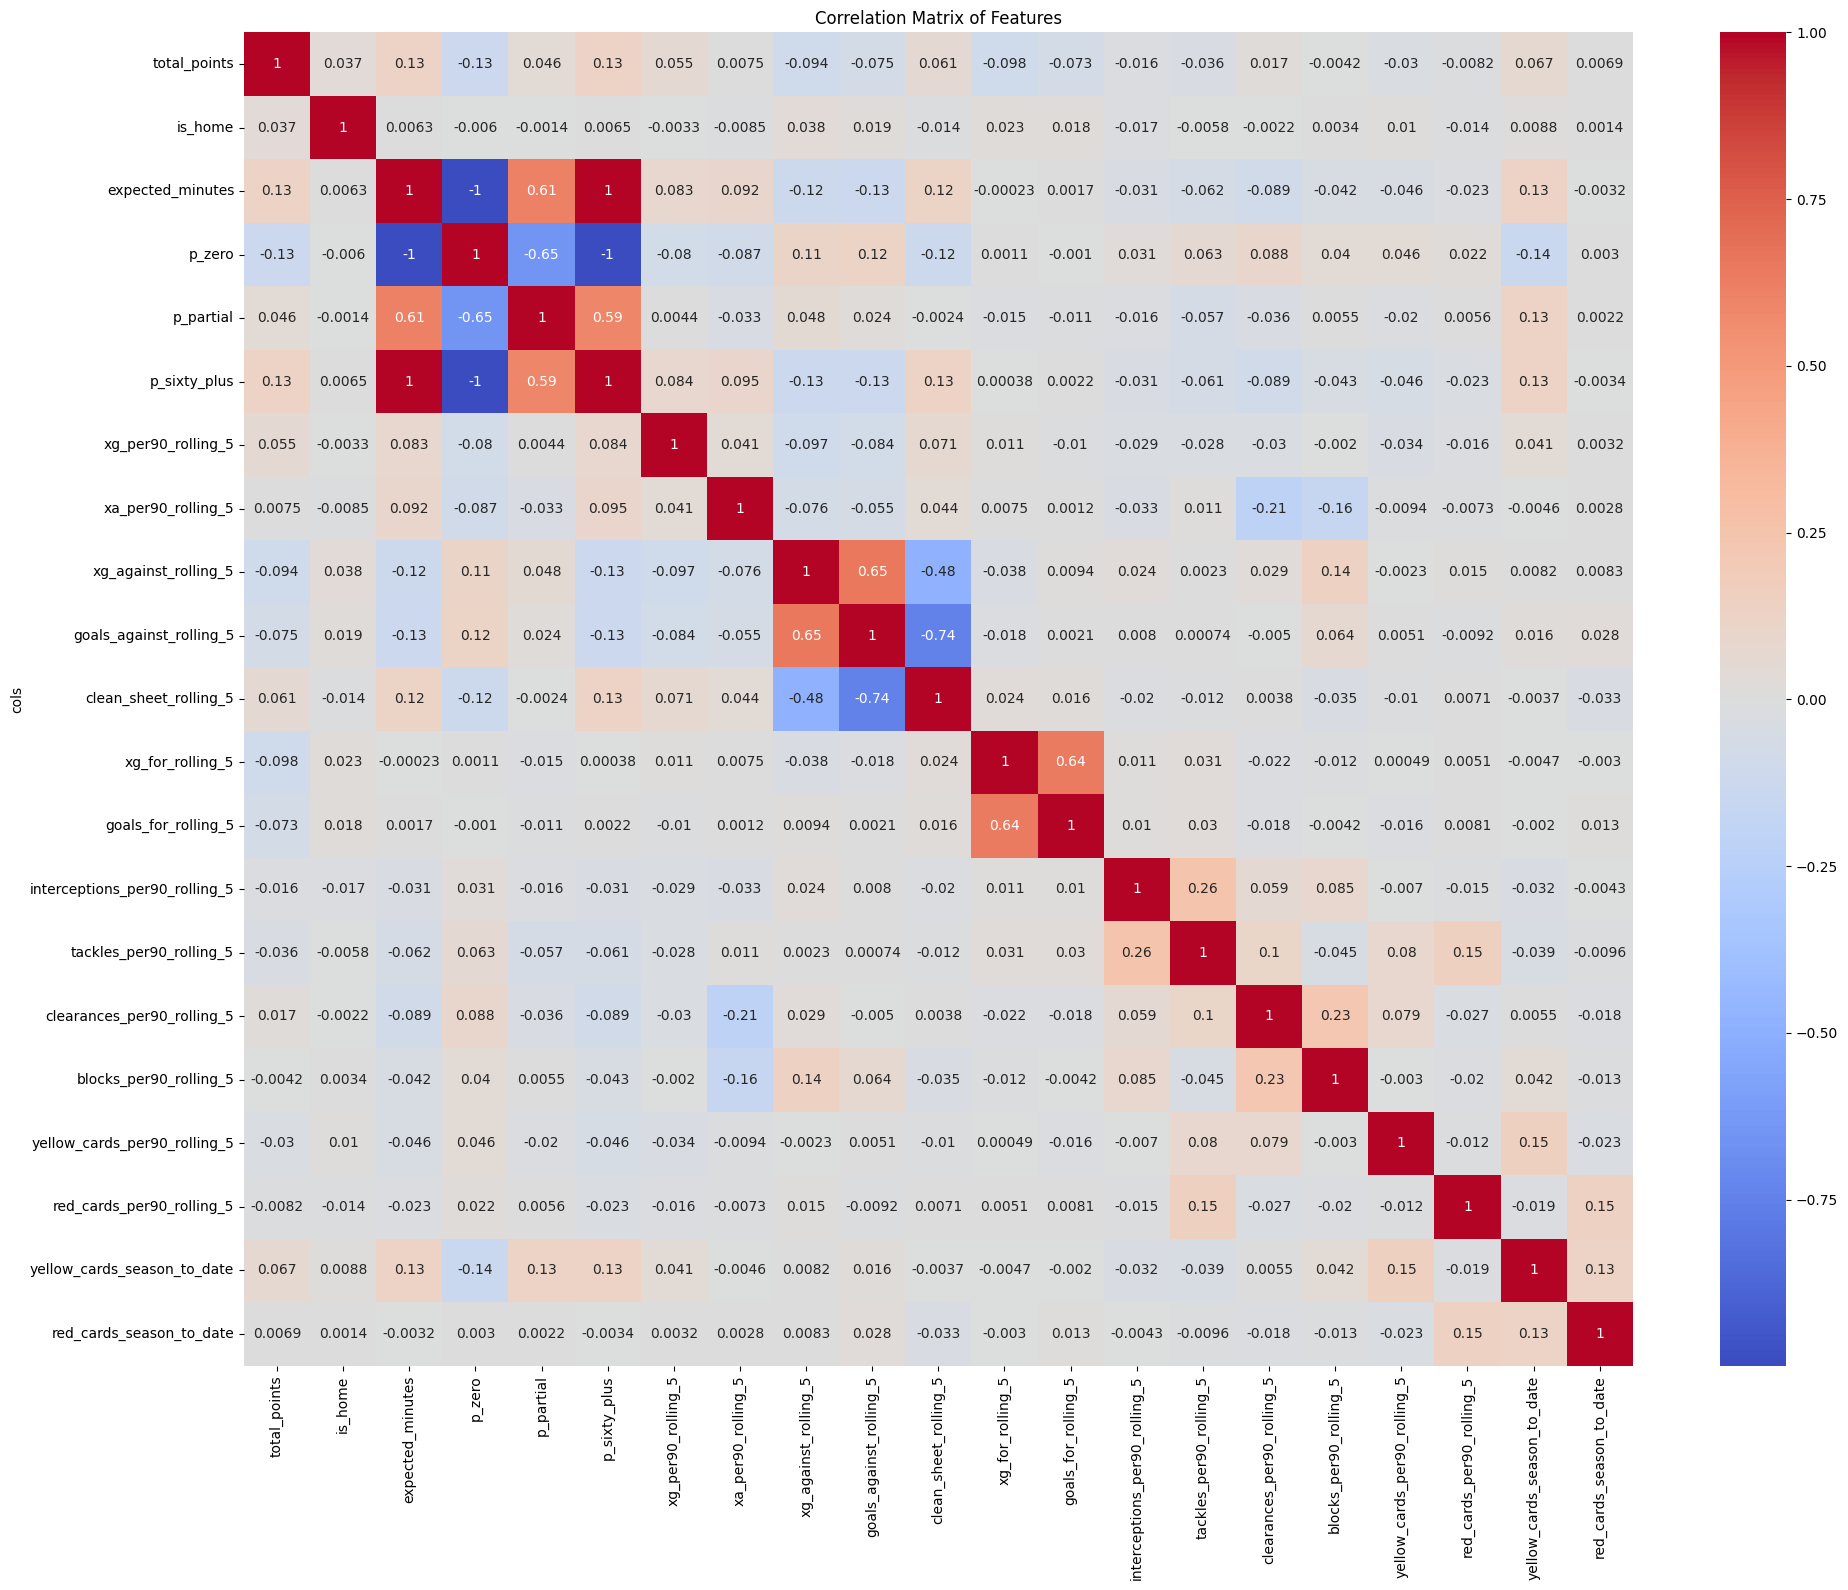

In [50]:
# make sure that the column names are passed to the correlation matrix
correlation_matrix = base.drop_nulls().corr(label="cols").to_pandas().set_index("cols")

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", ax=ax)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

# don't include all minutes based features
# maybe bring fouls in at some point
# XG figures highly correlated with goals


In [51]:
from sklearn.model_selection import train_test_split

X = base.drop(["total_points"])
y = base["total_points"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jamie/personal/fantasy_football/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error 

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.32
MSE: 4.78
RMSE: 2.19


In [56]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.03
MSE: 4.23
RMSE: 2.06
